<a href="https://colab.research.google.com/github/hykim-1/Study/blob/main/CNN_GRU_WISDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np, pandas as pd
from keras.utils import to_categorical
import matplotlib.pyplot as plt, seaborn as sns
import keras
from keras import layers
import tensorflow as tf

from sklearn.model_selection import train_test_split   # ★ 추가
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support

SEED=42
np.random.seed(SEED); tf.random.set_seed(SEED)

In [4]:
# ====== WISDM 데이터 로더 ======
def load_dataset(path):
    # 파일 읽기 (공백 구분이면 delim_whitespace=True, 콤마면 빼기)
    cols = ['idx', 'user', 'activity', 'timestamp', 'x', 'y', 'z']
    df = pd.read_csv(path, header=None, names=cols)  # 필요하면 delim_whitespace=True 추가

    # 1) Sitting / Jogging 만 남기기
    df = df[df['activity'].isin(['Sitting', 'Jogging'])].copy()

    # 2) x, y, activity 만 사용
    df = df[['x', 'y', 'activity']]

    # 3) 새 label 컬럼 (Sitting=0, Jogging=1)
    df['label'] = df['activity'].map({'Sitting': 0, 'Jogging': 1})

    X = df[['x', 'y']].values        # (전체 샘플 수, 2)
    y = df['label'].values           # (전체 샘플 수,)

    # ---- 시계열 윈도우 만들기 (CNN+GRU용) ----
    timesteps = 80        # 한 시퀀스 길이 (원하면 50, 100 등으로 바꿔도 됨)
    n_channels = 2        # x, y 두 개

    n_total = len(y)
    n_samples = n_total // timesteps   # 딱 나누어 떨어지는 부분까지만 사용
    X = X[:n_samples * timesteps]
    y = y[:n_samples * timesteps]

    # (샘플 수, timesteps, 채널 수) 로 reshape
    X = X.reshape(n_samples, timesteps, n_channels)
    # 각 윈도우의 label: 다수결(평균 0.5 기준)로 결정
    y = y.reshape(n_samples, timesteps)
    y = (y.mean(axis=1) >= 0.5).astype(int)

    # train / test 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    print("Shapes:",
          "trainX", X_train.shape, "trainy", y_train.shape,
          "| testX", X_test.shape, "testy", y_test.shape)

    return X_train, y_train, X_test, y_test

In [5]:

# 실제로 로드
data_path = "/content/drive/MyDrive/WISDM.csv"   # 네 파일 경로로 수정
X_train, y_train, X_test, y_test = load_dataset(data_path)

num_classes = len(np.unique(y_train))
y_train_oh = to_categorical(y_train, num_classes)
y_test_oh  = to_categorical(y_test,  num_classes)

timesteps, n_channels = X_train.shape[1], X_train.shape[2]
input_shape = (timesteps, n_channels)

Shapes: trainX (3808, 80, 2) trainy (3808,) | testX (952, 80, 2) testy (952,)


In [6]:

# ===== CNN + GRU 모델 =====
def build_cnn_gru(input_shape, num_classes):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GRU(128)(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN_GRU")

model = build_cnn_gru(input_shape, num_classes)
model.summary()

opt = keras.optimizers.Adam(1e-3)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)]

history = model.fit(
    X_train, y_train_oh,
    epochs=30, batch_size=64, verbose=2,
    callbacks=callbacks
)

Model: "CNN_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 80, 64)         │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 40, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,506 (490.26 KB)

 Trainable params: 125,122 (488.76 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
60/60 - 3s - 44ms/step - accuracy: 0.9779 - loss: 0.0684
Epoch 2/30
60/60 - 1s - 8ms/step - accuracy: 0.9950 - loss: 0.0215
Epoch 3/30
60/60 - 1s - 11ms/step - accuracy: 0.9971 - loss: 0.0134
Epoch 4/30
60/60 - 1s - 13ms/step - accuracy: 0.9974 - loss: 0.0112
Epoch 5/30
60/60 - 1s - 13ms/step - accuracy: 0.9953 - loss: 0.0158
Epoch 6/30
60/60 - 1s - 13ms/step - accuracy: 0.9968 - loss: 0.0120
Epoch 7/30
60/60 - 1s - 11ms/step - accuracy: 0.9987 - loss: 0.0043
Epoch 8/30
60/60 - 1s - 8ms/step - accuracy: 0.9992 - loss: 0.0034
Epoch 9/30
60/60 - 1s - 9ms/step - accuracy: 0.9995 - loss: 0.0025
Epoch 10/30
60/60 - 0s - 8ms/step - accuracy: 0.9992 - loss: 0.0024
Epoch 11/30
60/60 - 1s - 8ms/step - accuracy: 0.9984 - loss: 0.0031
Epoch 12/30
60/60 - 1s - 8ms/step - accuracy: 0.9997 - loss: 0.0011
Epoch 13/30
60/60 - 1s - 9ms/step - accuracy: 0.9997 - loss: 0.0021
Epoch 14/30
60/60 - 1s - 9ms/step - accuracy: 1.0000 - loss: 3.7029e-04
Epoch 15/30
60/60 - 0s - 8ms/step - accuracy: 1

In [7]:
# ===== 평가 =====
probs = model.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1); y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred); f1m = f1_score(y_true, y_pred, average="macro")
print(f"[TEST] Acc={acc:.4f} | Macro-F1={f1m:.4f}")
print("\n[TEST] Classification Report")
print(classification_report(y_true, y_pred, digits=4))


[TEST] Acc=0.9958 | Macro-F1=0.9914

[TEST] Classification Report
              precision    recall  f1-score   support

           0     1.0000    0.9708    0.9852       137
           1     0.9951    1.0000    0.9976       815

    accuracy                         0.9958       952
   macro avg     0.9976    0.9854    0.9914       952
weighted avg     0.9958    0.9958    0.9958       952



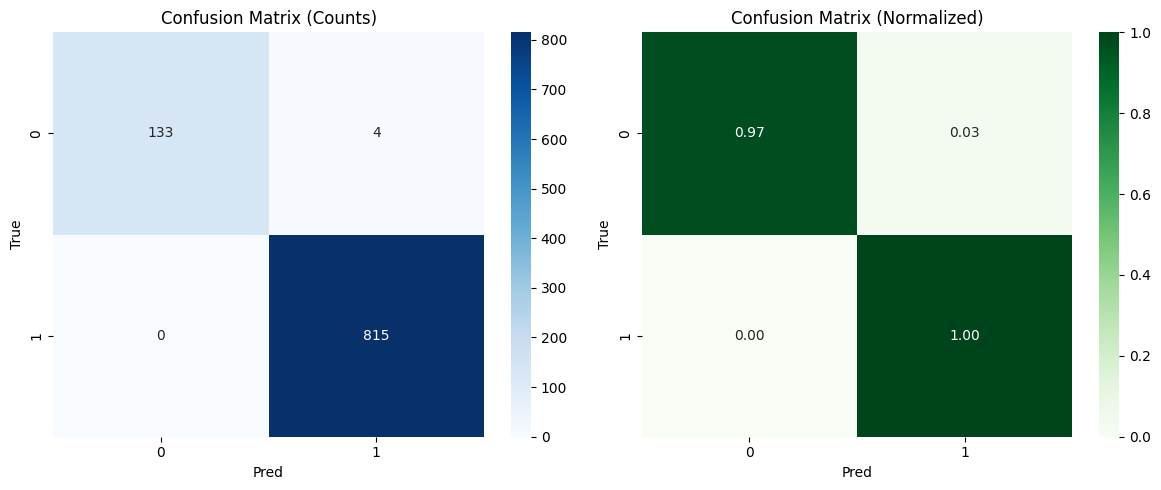

In [8]:


cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('Confusion Matrix (Counts)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.subplot(1,2,2); sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens'); plt.title('Confusion Matrix (Normalized)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.tight_layout(); plt.show()

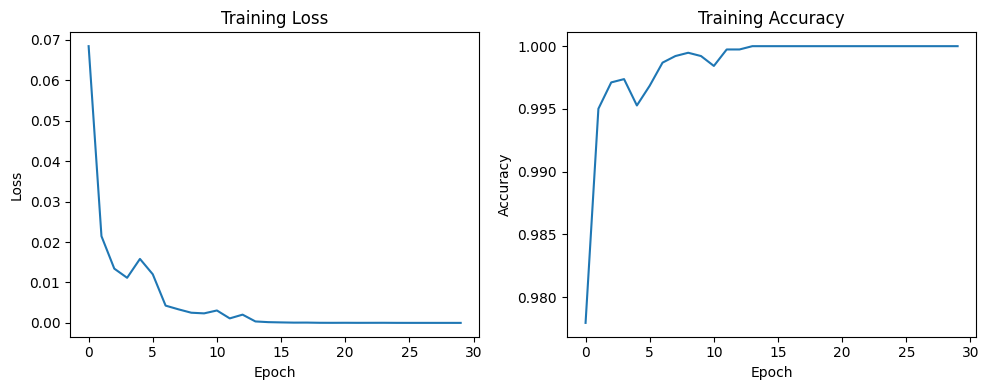

In [9]:


hist = history.history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist.get('loss', [])); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.subplot(1,2,2); plt.plot(hist.get('accuracy', [])); plt.title('Training Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.tight_layout(); plt.show()

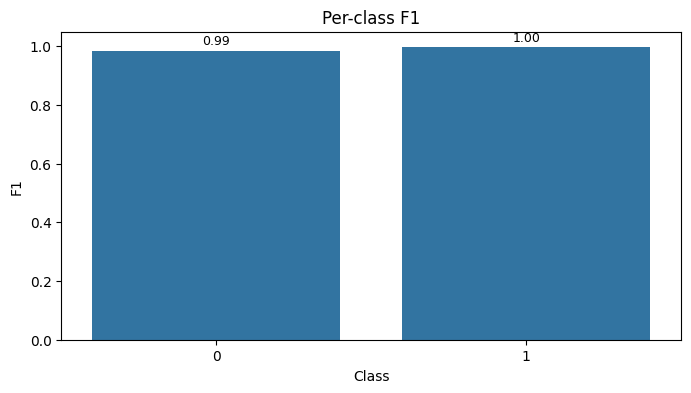

In [10]:

prec, rec, f1s, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
classes = np.arange(len(f1s))
plt.figure(figsize=(8,4))
sns.barplot(x=classes, y=f1s); plt.title('Per-class F1'); plt.xlabel('Class'); plt.ylabel('F1')
for i, v in enumerate(f1s):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9)
plt.ylim(0,1.05); plt.show()

In [11]:
print("\nTF:", tf.__version__, "| Keras:", keras.__version__, "| Backend:", keras.backend.backend())


TF: 2.19.0 | Keras: 3.10.0 | Backend: tensorflow
